In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import metrics
from sklearn.datasets import make_blobs
from sklearn.cluster import DBSCAN

In [5]:
x,y=make_blobs(n_samples=1000,centers=4,cluster_std=0.5,random_state=42)

In [12]:
db=DBSCAN(eps=0.3,min_samples=10)
db.fit(x)
core_sample_mask=np.zeros_like(db.labels_,dtype=bool)
core_sample_mask[db.core_sample_indices_]=True
labels=db.labels_
labelswithnoise=set(labels)
#eps شعاع دایره ای که دورش رو میبینه و داده هم کنارش نباشه میشه نویز

In [14]:
print(labelswithnoise)
#منفی ها نویز ها هستند

{0, 1, 2, 3, -1}


In [15]:
n_cluster=len(set(labels))-(1 if -1 in labels else 0)
unique_label=set(labels)
print(f"cluster={n_cluster}---unique_label={unique_label}")

cluster=4---unique_label={0, 1, 2, 3, -1}


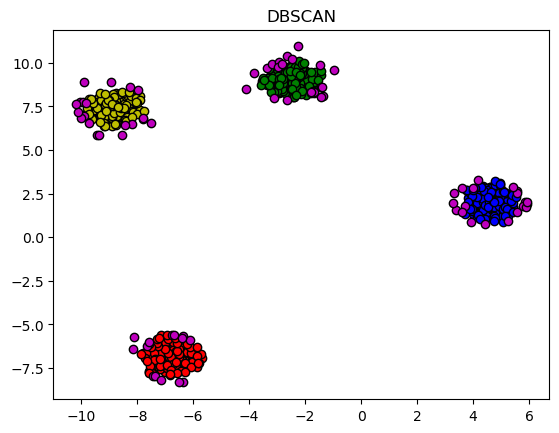

In [17]:
colors=["y","r","b","g","k"]
for k,col in zip(unique_label,colors):
    if k==-1:
        col="m"
#تفاوت نقاط بوردر و نویز که بردر ها حاشیه ای ممکنه باشند
    class_member_mask=(labels==k)
    xy=x[class_member_mask&core_sample_mask]
    plt.plot(xy[:,0],xy[:,1],"o",mfc=col,mec="k",ms=6)
    
    xy=x[class_member_mask&~core_sample_mask]
    plt.plot(xy[:,0],xy[:,1],"o",mfc=col,mec="k",ms=6)
    
    
plt.title("DBSCAN")
plt.show()

In [18]:
?DBSCAN